In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/alpertemel/turkey-car-market-2020

df = pd.read_csv("turkey_car_market.csv")

col_names = ["ilan_tarihi", "marka", "model", "tip", "model_yili", "yakit_turu",
             "vites", "ccm", "beygir_gucu", "renk", "kasa_tipi", "kimden", "durum", "km", "fiyat"]

df.columns = col_names
print("Kolon İsimleri:", df.columns)
print("\nVeri Boyutu:", df.shape)

Kolon İsimleri: Index(['ilan_tarihi', 'marka', 'model', 'tip', 'model_yili', 'yakit_turu',
       'vites', 'ccm', 'beygir_gucu', 'renk', 'kasa_tipi', 'kimden', 'durum',
       'km', 'fiyat'],
      dtype='object')

Veri Boyutu: (9044, 15)


In [3]:
df.head()

,ilan_tarihi,marka,model,tip,model_yili,yakit_turu,vites,ccm,beygir_gucu,renk,kasa_tipi,kimden,durum,km,fiyat
0,27/05/2020,Jaguar,XF,2.0 D Prestige Plus,2017.0,Dizel,Otomatik Vites,1801-2000 cc,176-200 BG,Lacivert,Hatchback 5 Kapı,Galeriden,2. El,26100,634500
1,16/06/2020,Acura,CL,-,2015.0,Dizel,Yarı Otomatik Vites,1301-1600 cc,101-125 BG,Mavi,Sedan,Sahibinden,2. El,127000,151500
2,14/06/2020,Acura,CL,2.2,1994.0,Benzin/LPG,Düz Vites,1301-1600 cc,101-125 BG,Turkuaz,Sedan,Sahibinden,2. El,175000,19750
3,11/06/2020,Acura,CL,-,2013.0,Dizel,Düz Vites,1301-1600 cc,76-100 BG,Kahverengi,Sedan,Sahibinden,2. El,325,52000
4,11/06/2020,Acura,CL,2.2,2010.0,Dizel,Otomatik Vites,1801-2000 cc,151-175 BG,Beyaz,Sedan,Sahibinden,2. El,207000,148750


In [4]:
# df["ilan_tarihi"] = pd.to_datetime(df["ilan_tarihi"], dayfirst=True)
df = df.drop("ilan_tarihi", axis=1)

# model yılını int yap.
df["model_yili"] = df["model_yili"].astype(int)

# renk kolonunu kaldır, fiyata çok bir etkisi yok
df = df.drop(columns=["renk", "ccm", "tip", "beygir_gucu"], axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9044 entries, 0 to 9043
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   marka       9044 non-null   object
 1   model       9044 non-null   object
 2   model_yili  9044 non-null   int64 
 3   yakit_turu  9044 non-null   object
 4   vites       9044 non-null   object
 5   kasa_tipi   9044 non-null   object
 6   kimden      9044 non-null   object
 7   durum       9044 non-null   object
 8   km          9044 non-null   int64 
 9   fiyat       9044 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 706.7+ KB


In [6]:
df.head()

,marka,model,model_yili,yakit_turu,vites,kasa_tipi,kimden,durum,km,fiyat
0,Jaguar,XF,2017,Dizel,Otomatik Vites,Hatchback 5 Kapı,Galeriden,2. El,26100,634500
1,Acura,CL,2015,Dizel,Yarı Otomatik Vites,Sedan,Sahibinden,2. El,127000,151500
2,Acura,CL,1994,Benzin/LPG,Düz Vites,Sedan,Sahibinden,2. El,175000,19750
3,Acura,CL,2013,Dizel,Düz Vites,Sedan,Sahibinden,2. El,325,52000
4,Acura,CL,2010,Dizel,Otomatik Vites,Sedan,Sahibinden,2. El,207000,148750


In [7]:
print(df["model"].value_counts().count())
print(df["marka"].value_counts().count())

387
36


In [8]:
del_cols = ["Alfa Romeo", "Lada", "Chrysler", "Infiniti", "Isuzu", "Rover", "Maserati", "Geely", "Chery", "Acura"]
df = df[~df["marka"].isin(del_cols)]

df = df[~df["yakit_turu"].isin(["Hibrit", "Elektrik"])]

df = df.reset_index(drop=True)

In [9]:
for col in ["yakit_turu", "vites", "kasa_tipi", "kimden", "durum"]:
    print(df[col].value_counts())
    print()

yakit_turu
Dizel         5831
Benzin/LPG    1648
Benzin        1432
Name: count, dtype: int64

vites
Düz Vites              4445
Otomatik Vites         2386
Yarı Otomatik Vites    2080
Name: count, dtype: int64

kasa_tipi
Sedan                    4583
Hatchback 5 Kapı         2279
Arazi Aracı              1188
Station Wagon             240
Camlı Van                 149
Spor / Coupe              146
Diğer                      90
MPV                        88
Hatchback 3 Kapı           79
Üstü Açık / Cabriolet      28
Crossover                  24
Roadster                    9
Minivan                     8
Name: count, dtype: int64

kimden
Galeriden     7277
Sahibinden    1583
Yetkili         51
Name: count, dtype: int64

durum
2. El      8648
0 km        215
Hasarlı      38
Klasik       10
Name: count, dtype: int64



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8911 entries, 0 to 8910
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   marka       8911 non-null   object
 1   model       8911 non-null   object
 2   model_yili  8911 non-null   int64 
 3   yakit_turu  8911 non-null   object
 4   vites       8911 non-null   object
 5   kasa_tipi   8911 non-null   object
 6   kimden      8911 non-null   object
 7   durum       8911 non-null   object
 8   km          8911 non-null   int64 
 9   fiyat       8911 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 696.3+ KB


In [11]:
print(df.shape)
df.groupby(["marka", "model"]).size().reset_index(name="adet").tail(5)

(8911, 10)


,marka,model,adet
366,Tofaş,Doğan,15
367,Tofaş,Kartal,8
368,Tofaş,Serçe,2
369,Tofaş,Şahin,20
370,Volkswagen,Polo,18


In [12]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,model_yili,km,fiyat
count,8911.00,8911.00,8911.00
mean,2011.85,136023.65,145874.98
std,6.58,93358.96,212929.93
min,1959.00,0.00,6250.00
25%,2010.00,68000.00,61000.00
50%,2014.00,126000.00,95500.00
75%,2017.00,194000.00,152500.00
max,2020.00,1850000.00,5086500.00


In [13]:
df[df["fiyat"] > 5000000]

,marka,model,model_yili,yakit_turu,vites,kasa_tipi,kimden,durum,km,fiyat
3401,Hyundai,I20,2013,Dizel,Düz Vites,Hatchback 5 Kapı,Sahibinden,2. El,140000,5086500


In [14]:
df = df[df["fiyat"] < 5000000]

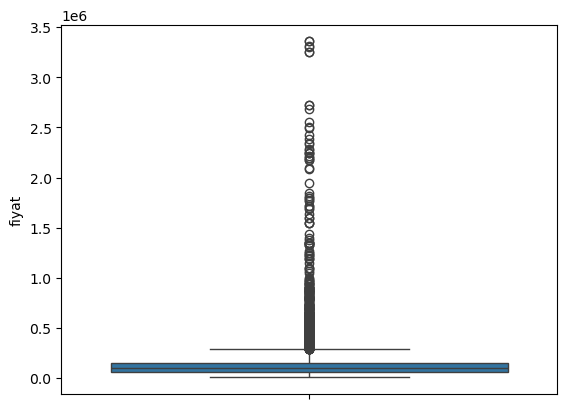

In [15]:
sns.boxplot(df["fiyat"])
plt.show()

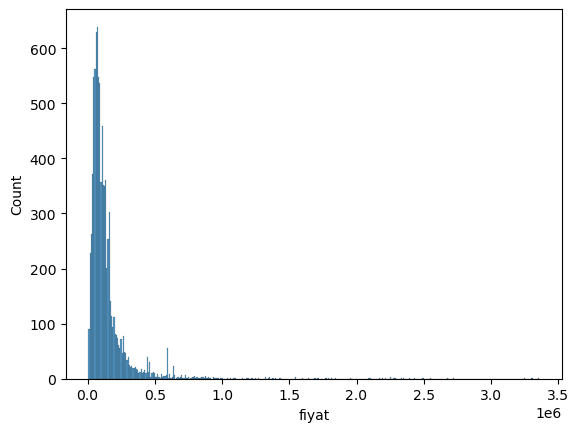

In [16]:
sns.histplot(df["fiyat"])
plt.show()

In [17]:
df[df["km"] > 750000]

,marka,model,model_yili,yakit_turu,vites,kasa_tipi,kimden,durum,km,fiyat
1141,Chevrolet,Kalos,2006,Benzin/LPG,Düz Vites,Hatchback 5 Kapı,Sahibinden,2. El,1850000,35500
4191,Mazda,626,1990,Benzin/LPG,Düz Vites,Sedan,Sahibinden,2. El,1111111,16500
5201,Opel,Meriva,2005,Benzin/LPG,Otomatik Vites,Hatchback 5 Kapı,Galeriden,Hasarlı,1111111,42500
6666,Renault,11,1988,Benzin/LPG,Düz Vites,Hatchback 5 Kapı,Sahibinden,2. El,1111111,11950
8876,Tofaş,Doğan,1993,Benzin/LPG,Düz Vites,Sedan,Galeriden,2. El,1000000,16250


In [18]:
df = df[df["km"] < 750000]

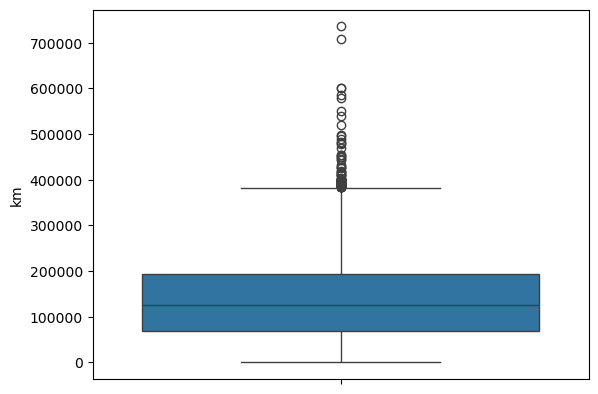

In [19]:
sns.boxplot(df["km"])
plt.show()

In [20]:
X = df.drop("fiyat", axis=1)
y = df["fiyat"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# CatBoost Regressor
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.04,
    depth=8,
    l2_leaf_reg=4,
    loss_function="RMSE",
    cat_features=["marka", "model", "yakit_turu", "vites", "kasa_tipi", "kimden", "durum"],
    random_state=42,
    verbose=100,
    early_stopping_rounds=50
)

In [23]:
# Train
model.fit(X_train, y_train)

0:	learn: 202670.1235735	total: 158ms	remaining: 1m 19s
100:	learn: 96097.1068133	total: 5.26s	remaining: 20.8s
200:	learn: 75850.3945307	total: 9.49s	remaining: 14.1s
300:	learn: 67865.6965258	total: 13.4s	remaining: 8.83s
400:	learn: 59875.2276019	total: 17.5s	remaining: 4.33s
499:	learn: 54876.9199436	total: 21.8s	remaining: 0us


In [24]:
# evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_pred = model.predict(X_test)
print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))

R2 Score:  0.8708710656051268
MSE: 5394129981.003592
MAE 25592.345033361285


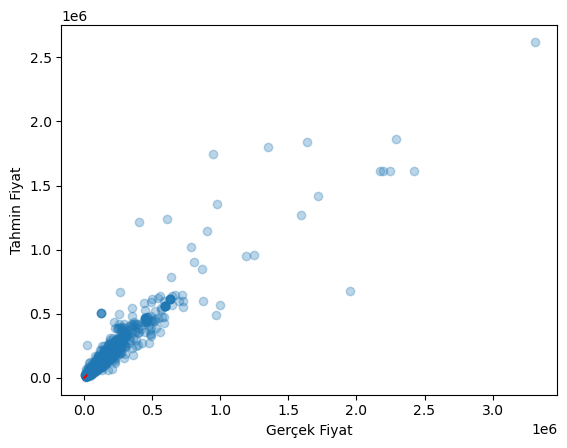

In [25]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,20000], [0,20000], color = "red")
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Fiyat")
plt.show()

In [26]:
"""
import pickle
with open("car_price_predictor.pkl", "wb") as f:
    pickle.dump(
        {
            "model":model
        }
    ,f)
"""

In [31]:
marka = list(df["marka"].value_counts().index)

In [32]:
marka

['Renault',
 'Fiat',
 'Opel',
 'Hyundai',
 'BMW',
 'Mercedes',
 'Ford',
 'Audi',
 'Peugeot',
 'Dacia',
 'Honda',
 'Skoda',
 'Nissan',
 'Citroen',
 'Land Rover',
 'Kia',
 'Seat',
 'Chevrolet',
 'Jeep',
 'Porsche',
 'Tofaş',
 'Mitsubishi',
 'Mini',
 'Jaguar',
 'Mazda',
 'Volkswagen']

In [33]:
modeli = list(df["model"].value_counts().index)
modeli

['Clio',
 'Megane',
 'Fluence',
 'Symbol',
 'Focus',
 'Astra',
 'Diğer',
 'Egea',
 '5 Serisi',
 '3 Serisi',
 'Civic',
 'C',
 'Linea',
 'Corsa',
 'A3',
 'Dokker',
 '301',
 'Fiesta',
 'E Serisi',
 'Accent Blue',
 'Octavia',
 'Qashqai',
 'Duster',
 'A4',
 'Captur',
 'Leon',
 'I20',
 'Insignia',
 'A6',
 'Accent Era',
 'Superb',
 'Sandero',
 'Accent',
 'Tucson',
 'Sportage',
 'Range Rover Sport',
 'A Serisi',
 '7 Serisi',
 'Vectra',
 '1 Serisi',
 'Punto',
 'X5',
 'Albea',
 'Getz',
 'Q7',
 '2008',
 '206',
 'Cherokee',
 '3008',
 'Cruze',
 'Range Rover',
 'CLA',
 'Elantra',
 '508',
 'Aveo',
 'Mondeo',
 'A5',
 'Palio',
 'Micra',
 '308',
 'Discovery Sport',
 'CR-V',
 'Fabia',
 'Vito',
 'E',
 'Captiva',
 'Cayenne',
 'C4',
 'Ibiza',
 'Juke',
 '207',
 '307',
 'Cerato',
 'Rio',
 'XF',
 'S Serisi',
 '4 Serisi',
 'Freelander',
 'Wrangler',
 'C-Elysee',
 'C5',
 'Tipo',
 'Laguna',
 'Şahin',
 'X-Trail',
 '19',
 'Rapid',
 'C3',
 'Megane II',
 'Uno',
 '208',
 'R 9',
 'Polo',
 '9',
 'Logan',
 'Siena',
 'Meg

In [34]:
marka_model_map = (
    df.groupby("marka")["model"]
      .unique()
      .apply(list)
      .to_dict()
)
marka_model_map

{'Audi': ['Q7',
  'A4',
  'A6',
  'A3',
  'A5',
  'Q5',
  'Q2',
  'Q8',
  '100 Serisi',
  'Q3',
  'TT',
  'A8',
  'RS',
  'A7',
  'S Serisi',
  'RS Q8'],
 'BMW': ['5 Serisi',
  '7 Serisi',
  '3 Serisi',
  '1 Serisi',
  'Diğer',
  'X3',
  'X5',
  '4 Serisi',
  'X6',
  'X1',
  '2 Serisi',
  'Z Serisi',
  '6 Serisi',
  'X2',
  'X4',
  'M Serisi'],
 'Chevrolet': ['Cruze',
  'Captiva',
  'Aveo',
  'Kalos',
  'Lacetti',
  'Trax',
  'Epica',
  'Diğer',
  'Camaro',
  'Avalanche',
  'Corvette',
  'Tahoe',
  'Blazer',
  'Nova'],
 'Citroen': ['C3',
  'Xsara',
  'C-Elysee',
  'Diğer',
  'Xantia',
  'C5',
  'C4',
  'CX',
  'C3 Picasso',
  'C4 Picasso',
  'C4 Grand Picasso',
  'Saxo',
  'C4 Cactus',
  'C2',
  'C5 AirCross',
  'DS4',
  '2CV',
  'C1'],
 'Dacia': ['Dokker', 'Duster', 'Sandero', '1310', 'Lodgy', 'Logan', 'Solenza'],
 'Fiat': ['Linea',
  'Egea',
  'Uno',
  'Siena',
  'Stilo',
  'Tipo',
  'Marea',
  'Punto',
  'Albea',
  'Palio',
  'Diğer',
  'Bravo',
  'Tempra',
  'Brava',
  '500L',
  'I